# RELIANCE.NS — Stock Price Prediction

**Regression models**
1. Linear Regression
2. Polynomial Regression
3. RBF Regressor (SVR)
4. Random Forest Regression

In [1]:
# Install dependencies (run once if needed)
!pip install -q yfinance pandas numpy matplotlib scikit-learn joblib

In [2]:
# Imports and configuration
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

warnings.filterwarnings("ignore")

TICKER = "RELIANCE.NS"
print("Stock:", TICKER)

Stock: RELIANCE.NS


In [3]:
# Download and clean historical data
data = yf.download(TICKER, period="max", auto_adjust=True, progress=False)

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

BASE_COLS = ["Open", "High", "Low", "Close", "Volume"]
missing = [c for c in BASE_COLS if c not in data.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

data = data[BASE_COLS].copy()
for col in BASE_COLS:
    data[col] = pd.to_numeric(data[col], errors="coerce")

data = (
    data.sort_index()
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
)

print(f"Rows: {len(data)}")
print(f"Period: {data.index.min()} to {data.index.max()}")
display(data.tail())

Rows: 7710
Period: 1996-01-01 00:00:00 to 2026-09-17 00:00:00


Price,Open,High,Low,Close,Volume
Date,,,,,
2026-09-11,1267.000000,1267.400024,1253.000000,1257.500000,8777736
2026-09-14,1257.500000,1257.500000,1257.500000,1257.500000,0
2026-09-15,1252.500000,1259.400024,1235.300049,1235.300049,13754376
2026-09-16,1243.000000,1255.000000,1240.000000,1240.000000,10023997
2026-09-17,1244.800049,1253.400024,1238.500000,1243.900024,7703749


In [4]:
# Feature engineering and target
df = data.copy()

# Returns and lagged prices
for n in [1, 2, 3, 5, 10]:
    df[f"Return_{n}"] = df["Close"].pct_change(n)

for n in [1, 2, 3, 5]:
    df[f"Close_Lag_{n}"] = df["Close"].shift(n)

# Moving averages
for n in [5, 10, 20, 50]:
    df[f"SMA_{n}"] = df["Close"].rolling(n).mean()

df["EMA_10"] = df["Close"].ewm(span=10, adjust=False).mean()
df["EMA_20"] = df["Close"].ewm(span=20, adjust=False).mean()

# Ratios and volatility
df["Close_SMA10_Ratio"] = df["Close"] / df["SMA_10"]
df["Close_SMA20_Ratio"] = df["Close"] / df["SMA_20"]
df["Volatility_5"] = df["Return_1"].rolling(5).std()
df["Volatility_10"] = df["Return_1"].rolling(10).std()
df["Volatility_20"] = df["Return_1"].rolling(20).std()

# Price ranges
df["High_Low_Range"] = (df["High"] - df["Low"]) / df["Close"]
df["Open_Close_Range"] = (df["Close"] - df["Open"]) / df["Open"]

# RSI
delta = df["Close"].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = avg_gain / avg_loss.replace(0, np.nan)
df["RSI_14"] = 100 - (100 / (1 + rs))

# MACD
ema12 = df["Close"].ewm(span=12, adjust=False).mean()
ema26 = df["Close"].ewm(span=26, adjust=False).mean()
df["MACD"] = ema12 - ema26
df["MACD_Signal"] = df["MACD"].ewm(span=9, adjust=False).mean()

# Volume
df["Volume_Change"] = df["Volume"].pct_change()
df["Volume_SMA_10"] = df["Volume"].rolling(10).mean()
df["Volume_Ratio"] = np.where(
    df["Volume_SMA_10"] != 0,
    df["Volume"] / df["Volume_SMA_10"],
    np.nan
)

# Target: next-day log return
df["Target_Return"] = np.log(df["Close"].shift(-1) / df["Close"])

FEATURES = [
    "Open", "High", "Low", "Close", "Volume",
    "Return_1", "Return_2", "Return_3", "Return_5", "Return_10",
    "Close_Lag_1", "Close_Lag_2", "Close_Lag_3", "Close_Lag_5",
    "SMA_5", "SMA_10", "SMA_20", "SMA_50",
    "EMA_10", "EMA_20",
    "Close_SMA10_Ratio", "Close_SMA20_Ratio",
    "Volatility_5", "Volatility_10", "Volatility_20",
    "High_Low_Range", "Open_Close_Range",
    "RSI_14", "MACD", "MACD_Signal",
    "Volume_Change", "Volume_Ratio"
]

# Remove invalid rows after all features are created
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=FEATURES + ["Target_Return"]).copy()

X = df[FEATURES].astype(np.float64)
y = df["Target_Return"].astype(np.float64)

assert np.isfinite(X.to_numpy()).all()
assert np.isfinite(y.to_numpy()).all()

print("Final dataset:", X.shape)
print("Features:", len(FEATURES))

Final dataset: (7542, 32)
Features: 32


In [5]:
# Chronological train/test split — no random shuffle
split = int(len(df) * 0.80)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print("Train:", X_train.shape, X_train.index.min(), "to", X_train.index.max())
print("Test :", X_test.shape, X_test.index.min(), "to", X_test.index.max())

Train: (6033, 32) 1996-03-08 00:00:00 to 2020-08-10 00:00:00
Test : (1509, 32) 2020-08-11 00:00:00 to 2026-09-16 00:00:00


In [6]:
# Train all four regression models with TimeSeriesSplit Walk-Forward Cross Validation
linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

polynomial_model = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("model", LinearRegression())
])

rbf_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR(kernel="rbf", C=5.0, gamma="scale", epsilon=0.005))
])

random_forest_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

models = {
    "Linear Regression": linear_model,
    "Polynomial Regression": polynomial_model,
    "RBF Regressor": rbf_model,
    "Random Forest": random_forest_model
}

tscv = TimeSeriesSplit(n_splits=5)
predictions = {}
for name, model in models.items():
    cv_accs = []
    for tr_idx, val_idx in tscv.split(X_train):
        model.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
        p_cv = model.predict(X_train.iloc[val_idx])
        cv_accs.append(((y_train.iloc[val_idx] > 0) == (p_cv > 0)).mean() * 100)
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)
    print(f"{name} trained (5-Fold TimeSeriesSplit CV Dir Acc: {np.mean(cv_accs):.2f}%).")


Linear Regression trained.
Polynomial Regression trained.
RBF Regressor trained.
Random Forest trained.


In [7]:
# Evaluate return prediction and convert predictions to next-day prices
current_close = df.loc[X_test.index, "Close"]
actual_return = y_test

comparison = pd.DataFrame(index=X_test.index)
comparison["Current_Close"] = current_close
comparison["Actual_Return"] = actual_return
comparison["Actual_Next_Close"] = current_close * np.exp(actual_return)

return_rows = []
price_rows = []
direction_rows = []

for name, pred_return in predictions.items():
    safe_name = name.replace(" ", "_").replace("-", "_")
    price_pred = current_close * np.exp(pred_return)
    comparison[f"{safe_name}_Price"] = price_pred

    return_rows.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred_return),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred_return)),
        "R2": r2_score(y_test, pred_return)
    })

    price_rows.append({
        "Model": name,
        "MAE": mean_absolute_error(comparison["Actual_Next_Close"], price_pred),
        "RMSE": np.sqrt(mean_squared_error(comparison["Actual_Next_Close"], price_pred)),
        "R2": r2_score(comparison["Actual_Next_Close"], price_pred)
    })

    direction_rows.append({
        "Model": name,
        "Directional Accuracy (%)": ((y_test > 0) == (pred_return > 0)).mean() * 100
    })

return_results = pd.DataFrame(return_rows).sort_values("RMSE")
price_results = pd.DataFrame(price_rows).sort_values("RMSE")
direction_results = pd.DataFrame(direction_rows)

print("Return-level performance")
display(return_results)

print("Price-level performance")
display(price_results)

print("Directional accuracy")
display(direction_results)

Return-level performance


,Model,MAE,RMSE,R2
3,Random Forest,0.011133,0.015124,-0.078094
0,Linear Regression,0.012533,0.016684,-0.311951
2,RBF Regressor,0.030490,0.038544,-6.002300
1,Polynomial Regression,0.054888,0.081717,-30.473739


Price-level performance


,Model,MAE,RMSE,R2
3,Random Forest,13.337498,18.081944,0.990362
0,Linear Regression,15.142643,20.254714,0.987906
2,RBF Regressor,35.733213,43.069812,0.945318
1,Polynomial Regression,68.473519,114.403111,0.614188


Directional accuracy


,Model,Directional Accuracy (%)
0,Linear Regression,49.304175
1,Polynomial Regression,50.165673
2,RBF Regressor,50.960901
3,Random Forest,48.575215


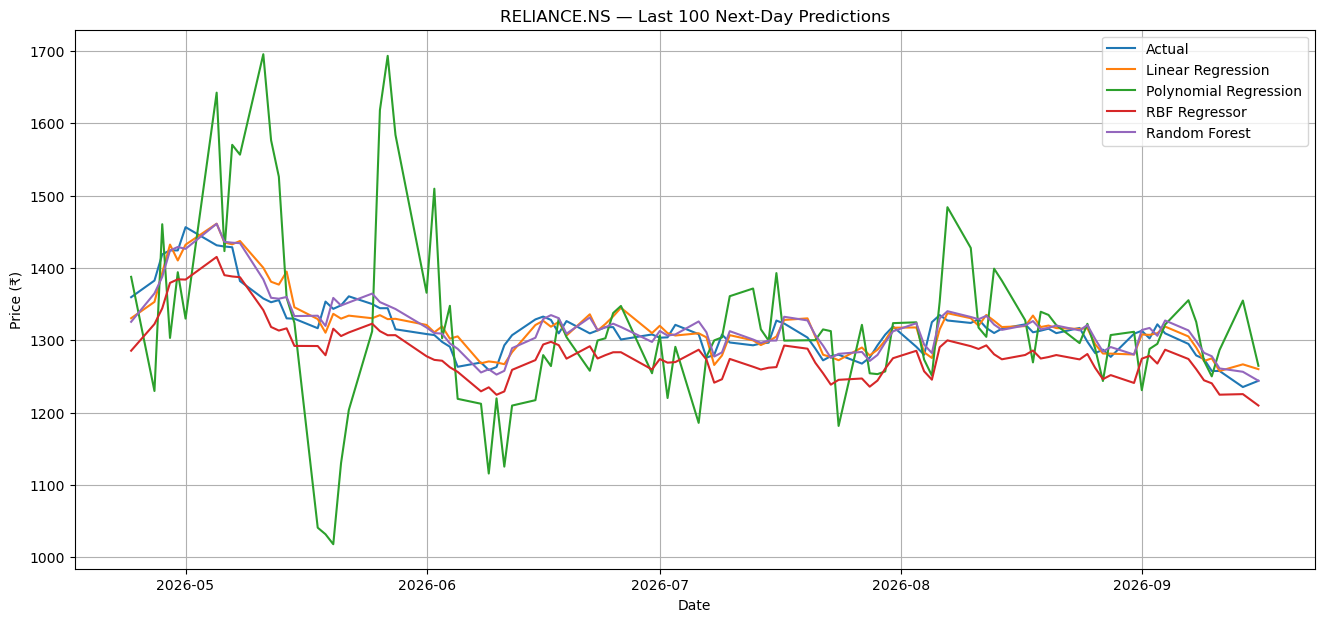

In [8]:
# Actual vs predicted prices — last 100 test observations
last = comparison.tail(100)

plt.figure(figsize=(16, 7))
plt.plot(last.index, last["Actual_Next_Close"], label="Actual")

for name in predictions:
    safe_name = name.replace(" ", "_").replace("-", "_")
    plt.plot(last.index, last[f"{safe_name}_Price"], label=name)

plt.title(f"{TICKER} — Last 100 Next-Day Predictions")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
# Random Forest feature importance
importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": random_forest_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(importance.head(15))

,Feature,Importance
21,Close_SMA20_Ratio,0.098131
9,Return_10,0.090593
27,RSI_14,0.070882
5,Return_1,0.056256
8,Return_5,0.055383
23,Volatility_10,0.055162
20,Close_SMA10_Ratio,0.053491
6,Return_2,0.049982
7,Return_3,0.049109
22,Volatility_5,0.043350


In [10]:
# Predict the next trading day using all four models
latest_X = df[FEATURES].iloc[[-1]]
current_price = float(df["Close"].iloc[-1])

final_rows = []
for name, model in models.items():
    predicted_return = float(model.predict(latest_X)[0])
    predicted_price = current_price * np.exp(predicted_return)

    final_rows.append({
        "Model": name,
        "Current Price": current_price,
        "Predicted Price": predicted_price,
        "Change": predicted_price - current_price,
        "Change %": ((predicted_price - current_price) / current_price) * 100,
        "Direction": "UP" if predicted_return > 0 else "DOWN"
    })

final_predictions = pd.DataFrame(final_rows)
display(final_predictions)

,Model,Current Price,Predicted Price,Change,Change %,Direction
0,Linear Regression,1240.0,1260.025648,20.025648,1.614972,UP
1,Polynomial Regression,1240.0,1264.675164,24.675164,1.989933,UP
2,RBF Regressor,1240.0,1209.753997,-30.246003,-2.439194,DOWN
3,Random Forest,1240.0,1243.975589,3.975589,0.320612,UP


In [11]:
# Save trained models and required feature list
os.makedirs("models", exist_ok=True)

for filename, model in {
    "linear_regression_model.pkl": linear_model,
    "polynomial_regression_model.pkl": polynomial_model,
    "rbf_regressor_model.pkl": rbf_model,
    "random_forest_model.pkl": random_forest_model
}.items():
    joblib.dump(model, os.path.join("models", filename))

joblib.dump(FEATURES, "models/model_features.pkl")

# Save results for the frontend/report
return_results.to_csv("model_return_performance.csv", index=False)
price_results.to_csv("model_price_performance.csv", index=False)
direction_results.to_csv("model_direction_accuracy.csv", index=False)
comparison.to_csv("all_model_predictions.csv")

print("Models and result files saved successfully.")

Models and result files saved successfully.
